# Optokæde: enkelt estimat af fotostrøm

Formålet med notebooken er at vise, hvordan størrelsesordenen for fotostrømmen i TIA-trinnet blev valgt.

Fotodioden er koblet i photovoltaic mode uden ekstern bias. Anoden er koblet til jord, og katoden ligger på op-ampens inverterende virtuelle jord. For dimensionering bruger vi derfor størrelsen af fotostrømmen:

$$
I_{ph} \approx \frac{|V_{out}|}{R_f}
$$

Her er $R_f$ feedbackmodstanden i transimpedansforstærkeren.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:.4g}".format

## 1. Faste kredsløbsværdier

Feedbackmodstanden var $2.21\ \mathrm{M\Omega}$. Gain-trinnet efter lavpasfilteret havde ideelt gain:

$$
1 + \frac{39\ \mathrm{k\Omega}}{10\ \mathrm{k\Omega}} = 4.9
$$

Gain-trinnet bruges kun som et AC-krydstjek. Selve TIA-dimensioneringen baseres på den direkte TIA-måling.

In [10]:
modstand_tilbagekobling_ohm = 2_210_000
forstærkning_gaintrin = 1 + 39_000 / 10_000

print(f"Feedbackmodstand: {modstand_tilbagekobling_ohm / 1e6:.2f} MΩ")
print(f"Gain-trin: {forstærkning_gaintrin:.1f}x")

Feedbackmodstand: 2.21 MΩ
Gain-trin: 4.9x


## 2. Hardcodede scope-målinger

Tabellen nedenfor indeholder medianværdier fra de relevante oscilloskopmålinger. Det er nok til formålet her, fordi notebooken kun skal give et realistisk estimat af fotostrømmens størrelsesorden.

For de direkte TIA- og LPF-målinger bruges $I_{ph} \approx |V|/R_f$. For `TIA + LPF + gain` divideres medianen først med gain-trinnets forstærkning, så værdien bliver sammenlignelig med TIA-outputtet.

In [11]:
målinger = pd.DataFrame(
    [
        {
            "måling": "TIA LED slukket",
            "spænding_median_V": 0.7747,
            "forstærkning": 1.0,
        },
        {
            "måling": "TIA LED tændt",
            "spænding_median_V": 0.5408,
            "forstærkning": 1.0,
        },
        {
            "måling": "TIA + LPF tændt",
            "spænding_median_V": 0.6514,
            "forstærkning": 1.0,
        },
        {
            "måling": "TIA + LPF + gain tændt",
            "spænding_median_V": 3.241,
            "forstærkning": forstærkning_gaintrin,
        },
    ]
).set_index("måling")

målinger["ækvivalent_tia_spænding_V"] = målinger["spænding_median_V"] / målinger["forstærkning"]
målinger["fotostrøm_estimat_nA"] = np.abs(målinger["ækvivalent_tia_spænding_V"]) / modstand_tilbagekobling_ohm * 1e9

målinger

,spænding_median_V,forstærkning,ækvivalent_tia_spænding_V,fotostrøm_estimat_nA
måling,,,,
TIA LED slukket,0.7747,1,0.7747,350.5
TIA LED tændt,0.5408,1,0.5408,244.7
TIA + LPF tændt,0.6514,1,0.6514,294.8
TIA + LPF + gain tændt,3.241,4.9,0.6614,299.3


## 3. Valgt dimensioneringspunkt

Den mest direkte måling er `TIA LED tændt`, fordi den ligger før LPF og gain-trin. Den bruges derfor som hovedestimat. De senere trin bruges som kontrol af, at størrelsesordenen stadig er den samme.

In [12]:
tia_tændt = målinger.loc["TIA LED tændt"]
typisk_fotostrøm_nA = tia_tændt["fotostrøm_estimat_nA"]

print(f"Typisk fotostrøm: {typisk_fotostrøm_nA:.0f} nA = {typisk_fotostrøm_nA / 1000:.3f} uA")
print(
    f"Medianen {tia_tændt['spænding_median_V']:.3f} V svarer til "
    f"{typisk_fotostrøm_nA:.0f} nA ved {modstand_tilbagekobling_ohm / 1e6:.2f} MΩ."
)

Typisk fotostrøm: 245 nA = 0.245 uA
Medianen 0.541 V svarer til 245 nA ved 2.21 MΩ.


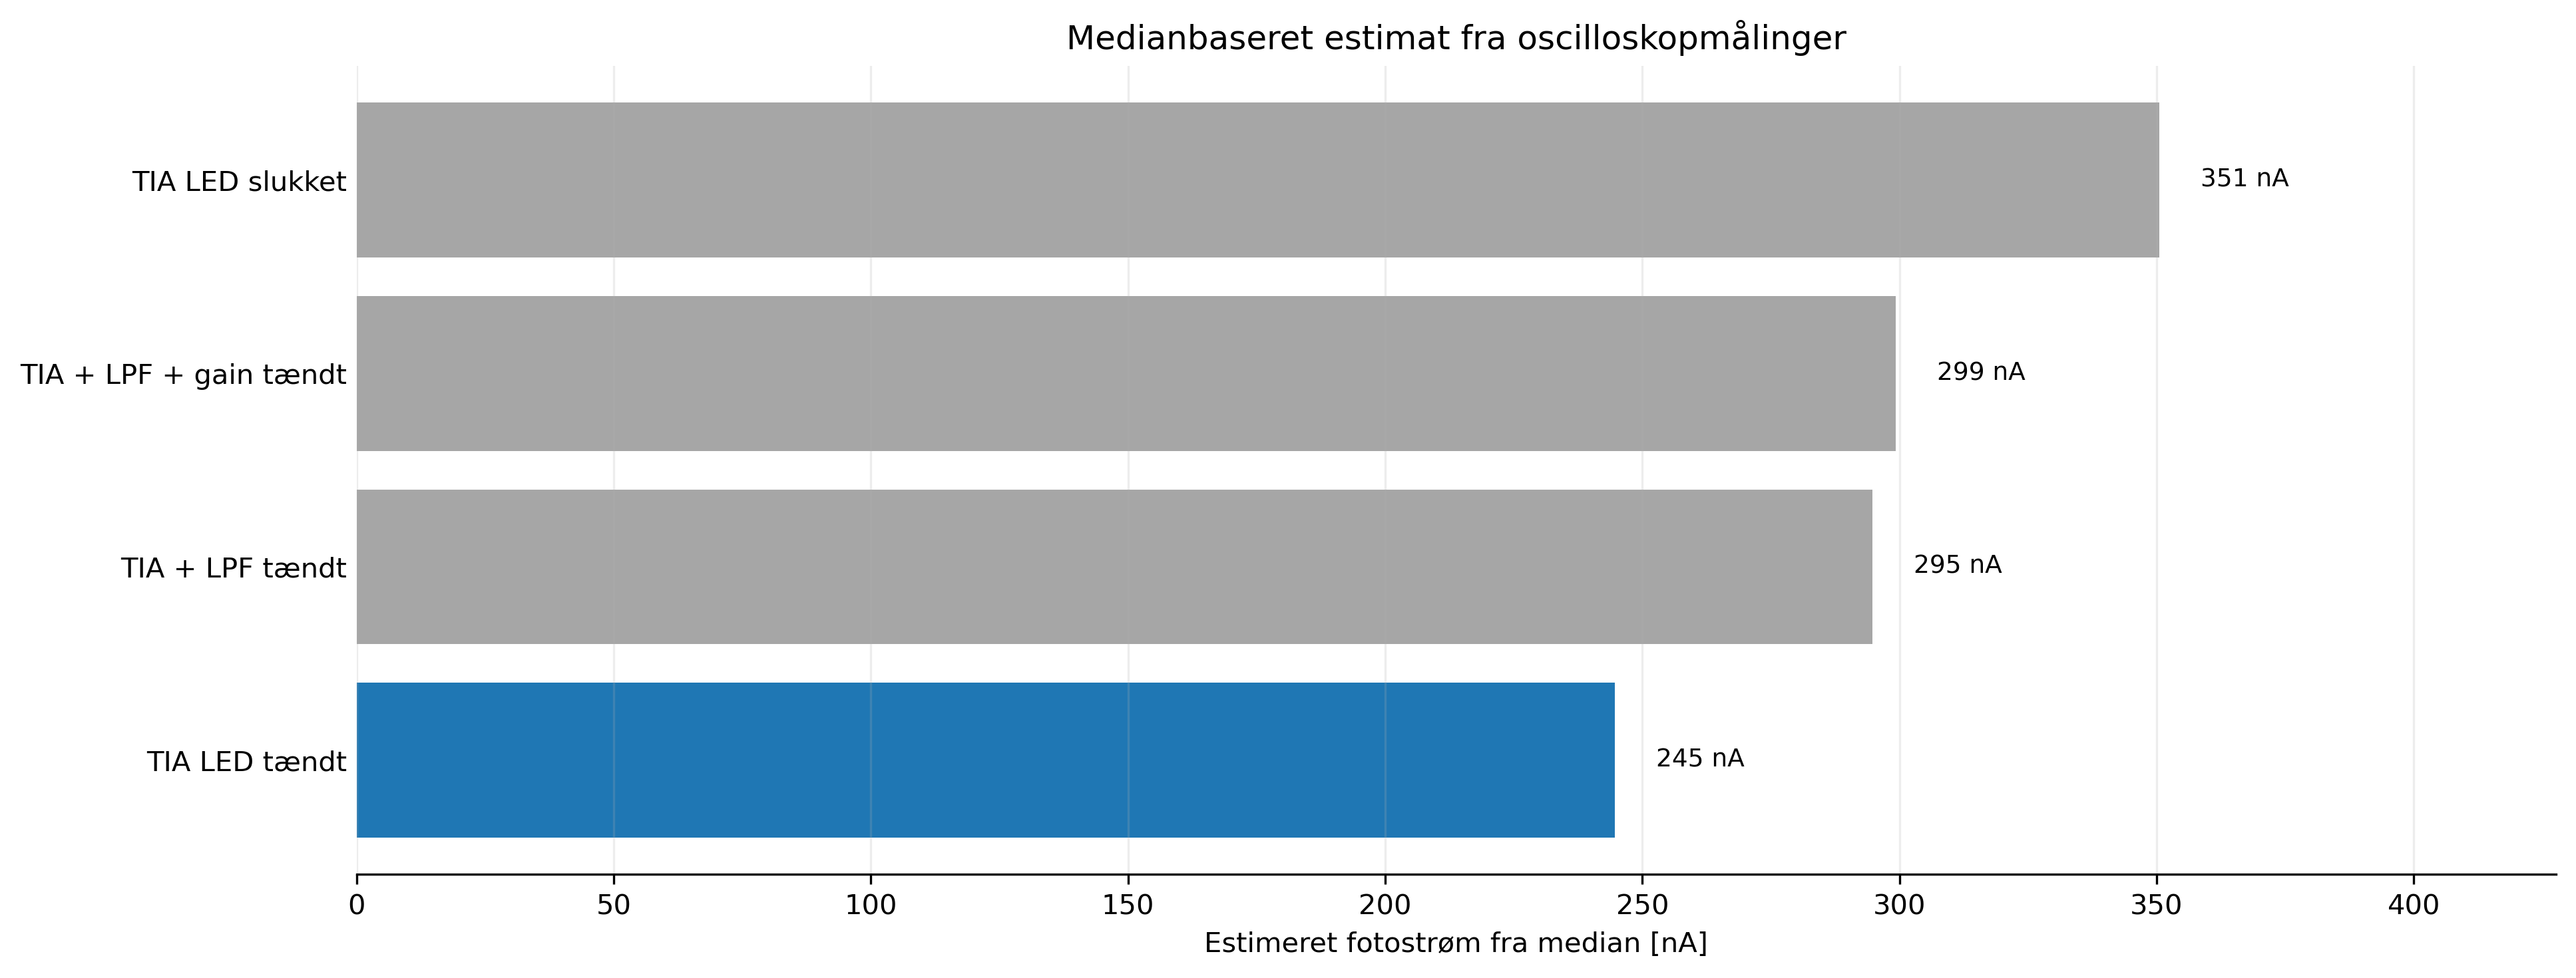

In [13]:
plotdata = målinger.sort_values("fotostrøm_estimat_nA")
farver = ["tab:blue" if indeks == "TIA LED tændt" else "0.65" for indeks in plotdata.index]

figur, akse = plt.subplots(figsize=(13, 5), dpi=300)
søjler = akse.barh(plotdata.index, plotdata["fotostrøm_estimat_nA"], color=farver)

for søjle in søjler:
    bredde = søjle.get_width()
    akse.text(
        bredde + 8,
        søjle.get_y() + søjle.get_height() / 2,
        f"{bredde:.0f} nA",
        va="center",
        fontsize=9,
    )

akse.set_xlabel("Estimeret fotostrøm fra median [nA]")
akse.set_title("Medianbaseret estimat fra oscilloskopmålinger")
akse.set_xlim(0, plotdata["fotostrøm_estimat_nA"].max() * 1.22)
akse.grid(axis="x", alpha=0.22)
akse.spines[["top", "right", "left"]].set_visible(False)
akse.tick_params(axis="y", length=0)
figur.tight_layout()
plt.show()

## 4. Optisk sanity check

Den simple optiske beregning nedenfor er kun en størrelsesordensmodel. Den antager ideel LED-retning, simpelt geometrisk overlap og grov fingertransmission. Den mangler især spredning i finger, mekanisk alignment, koblingstab og fotodiodens effektive vinkel.

Pointen er derfor ikke at dimensionere TIA'en fra den optiske model alene, men at vise hvorfor scope-målingen er mere realistisk.

In [14]:
# LED og fotodiode
lysstyrke_rød_cd = 1.95
fotopisk_følsomhed_660 = 0.05
strålingsintensitet_660_W_sr = lysstyrke_rød_cd / (683 * fotopisk_følsomhed_660)
strålingsintensitet_930_W_sr = 0.06

responsivitet_660_A_W = 0.46
responsivitet_930_A_W = 0.60

fotodiode_areal_m2 = 0.0024 * 0.0028
afstand_led_fotodiode_m = 0.012
rumvinkel_fotodiode_sr = fotodiode_areal_m2 / afstand_led_fotodiode_m**2
mekanisk_transmission = 0.7

# Grov fingertransmission
spo2_antaget = 0.98
hæmoglobin_effektiv_mM = 0.010
blodvej_cm = 0.10
vævstransmission = 0.30

absorptionskoefficient_660 = spo2_antaget * 350 + (1 - spo2_antaget) * 3800
absorptionskoefficient_930 = spo2_antaget * 800 + (1 - spo2_antaget) * 1300
dæmpning_660 = absorptionskoefficient_660 * hæmoglobin_effektiv_mM * np.log(10)
dæmpning_930 = absorptionskoefficient_930 * hæmoglobin_effektiv_mM * np.log(10)
fingertransmission_660 = vævstransmission * np.exp(-dæmpning_660 * blodvej_cm)
fingertransmission_930 = vævstransmission * np.exp(-dæmpning_930 * blodvej_cm)

effekt_fotodiode_660_W = strålingsintensitet_660_W_sr * rumvinkel_fotodiode_sr * mekanisk_transmission * fingertransmission_660
effekt_fotodiode_930_W = strålingsintensitet_930_W_sr * rumvinkel_fotodiode_sr * mekanisk_transmission * fingertransmission_930

naiv_strøm_660_A = responsivitet_660_A_W * effekt_fotodiode_660_W
naiv_strøm_930_A = responsivitet_930_A_W * effekt_fotodiode_930_W

målt_typisk_strøm_A = typisk_fotostrøm_nA * 1e-9

optisk_tabel = pd.DataFrame(
    [
        {
            "LED": "Rød 660 nm",
            "strålingsintensitet_W_sr": strålingsintensitet_660_W_sr,
            "fingertransmission": fingertransmission_660,
            "naiv_effekt_på_fotodiode_uW": effekt_fotodiode_660_W * 1e6,
            "naiv_fotostrøm_uA": naiv_strøm_660_A * 1e6,
            "ekstra_tab_for_at_matche_scope": målt_typisk_strøm_A / naiv_strøm_660_A,
        },
        {
            "LED": "IR 930 nm",
            "strålingsintensitet_W_sr": strålingsintensitet_930_W_sr,
            "fingertransmission": fingertransmission_930,
            "naiv_effekt_på_fotodiode_uW": effekt_fotodiode_930_W * 1e6,
            "naiv_fotostrøm_uA": naiv_strøm_930_A * 1e6,
            "ekstra_tab_for_at_matche_scope": målt_typisk_strøm_A / naiv_strøm_930_A,
        },
    ]
).set_index("LED")

optisk_tabel

,strålingsintensitet_W_sr,fingertransmission,naiv_effekt_på_fotodiode_uW,naiv_fotostrøm_uA,ekstra_tab_for_at_matche_scope
LED,,,,,
Rød 660 nm,0.0571,0.1143,213.2,98.09,0.002495
IR 930 nm,0.06,0.04646,91.07,54.64,0.004478


Den naive optiske model giver fotostrømme i størrelsesordenen titusinder til hundredtusinder nA. Scope-målingen ligger derimod omkring få hundrede nA. Det viser, at de reelle optiske tab i opstillingen er store, og at scope-målingen er det bedste grundlag for TIA-dimensioneringen.

## 5. Hvilken feedbackmodstand passer?

Her sammenlignes det valgte medianestimat med nogle ønskede TIA-output. Det viser, at $R_f \approx 2.1-2.2\ \mathrm{M\Omega}$ giver et fornuftigt niveau: omkring 0.5 V ved den typiske målte fotostrøm.

In [15]:
dimensioneringsstrømme_nA = pd.Series(
    {
        "typisk fra TIA LED tændt": typisk_fotostrøm_nA,
        "gain-korrigeret median": målinger.loc["TIA + LPF + gain tændt", "fotostrøm_estimat_nA"],
        "1 uA sikkerhedstjek": 1000,
    },
    name="fotostrøm_nA",
)

dimensionering = pd.DataFrame(index=dimensioneringsstrømme_nA.index)
dimensionering["fotostrøm_uA"] = dimensioneringsstrømme_nA / 1000
dimensionering["output_ved_2_21_Mohm_V"] = dimensioneringsstrømme_nA * 1e-9 * modstand_tilbagekobling_ohm

for målspænding_V in [0.3, 0.5, 1.0, 2.5]:
    kolonnenavn = f"Rf_for_{målspænding_V:g}_V_Mohm"
    dimensionering[kolonnenavn] = målspænding_V / (dimensioneringsstrømme_nA * 1e-9) / 1e6

dimensionering

,fotostrøm_uA,output_ved_2_21_Mohm_V,Rf_for_0.3_V_Mohm,Rf_for_0.5_V_Mohm,Rf_for_1_V_Mohm,Rf_for_2.5_V_Mohm
typisk fra TIA LED tændt,0.2447,0.5408,1.226,2.043,4.087,10.22
gain-korrigeret median,0.2993,0.6614,1.002,1.671,3.341,8.353
1 uA sikkerhedstjek,1,2.21,0.3,0.5,1,2.5


## Konklusion

Et realistisk estimat for fotostrømmen i TIA-trinnet er:

$$
I_{ph} \approx 0.25\ \mu A
$$

Gain-målingen giver efter korrektion for forstærkningen et estimat på cirka $0.30\ \mu A$, så den ligger i samme størrelsesorden som den direkte TIA-måling.

Derfor er $R_f = 2.21\ \mathrm{M\Omega}$ plausibel: den giver ca. `0.54 V` ved typisk målt fotostrøm. Den simple optiske model bruges kun som sanity check, fordi den ikke indeholder alle de praktiske optiske tab i opstillingen.

----------

In [16]:
245e-9 * 2.21e6

0.54145

In [23]:
29/0.48

60.41666666666667